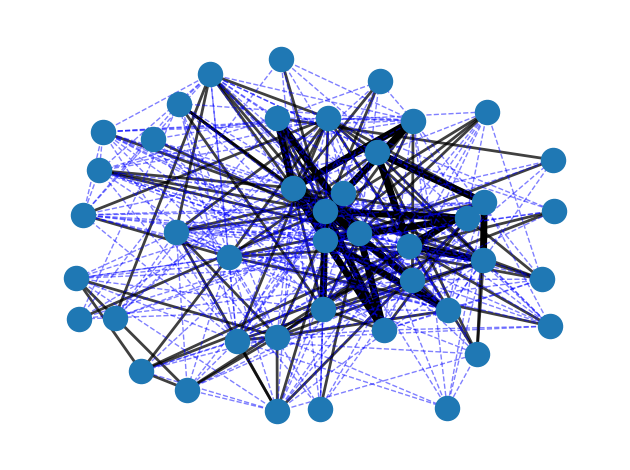

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

g = nx.read_weighted_edgelist("./ignore-files/out.moreno_beach_beach", delimiter=" ",comments='%',nodetype=int)

elarge = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 10]
emedium = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 2 and d['weight'] <= 10]
esmall = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] <= 2]
pos = nx.spring_layout(g, seed=7, k=3, gravity=2)  # positions for all nodes - seed for reproducibility
# nodes
nx.draw_networkx_nodes(g, pos)

# edges
nx.draw_networkx_edges(g, pos, edgelist=elarge, width=5)
nx.draw_networkx_edges(g, pos, edgelist=emedium, width=2, alpha=0.75)
nx.draw_networkx_edges(
    g, pos, edgelist=esmall, width=1, alpha=0.5, edge_color="b", style="dashed"
)

# node labels
# nx.draw_networkx_labels(g, pos, font_family="sans-serif")
# edge weight labels
# edge_labels = nx.get_edge_attributes(g, "weight")
# nx.draw_networkx_edge_labels(g, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

def animate_epidemic_simple(graph_file, events_file, model_type='SIR'):
    # Cargar datos
    g = nx.read_edgelist(graph_file, nodetype=int, delimiter=' ', comments='%')
    events = pd.read_csv(events_file, delimiter=' ', comment='%',
                         names=['time', 'action', 'node'])
    
    # Configurar figura
    fig, ax = plt.subplots(figsize=(10, 8))
    pos = nx.spring_layout(g, seed=42)
    
    # Estado inicial
    states = {node: 'S' for node in g.nodes()}
    
    # Colores
    color_map = {'S': 'lightblue', 'I': 'red', 'R': 'green'}
    
    def update(frame):
        ax.clear()
        
        # Aplicar eventos hasta este frame
        current_events = events[events.index < frame]
        current_states = states.copy()
        
        for _, event in current_events.iterrows():
            node = event['node']
            if event['action'] == 'I':
                current_states[node] = 'I'
            elif event['action'] == 'R' and model_type == 'SIR':
                current_states[node] = 'R'
            elif event['action'] == 'R' and model_type == 'SIS':
                current_states[node] = 'S'
        
        # Colorear nodos
        node_colors = [color_map[current_states[n]] for n in g.nodes()]
        
        # Dibujar
        nx.draw(g, pos, node_color=node_colors, 
                node_size=200, ax=ax, with_labels=True)
        
        # Título con tiempo
        if not current_events.empty:
            current_time = current_events.iloc[-1]['time']
            ax.set_title(f'Tiempo: {current_time:.2f}')
        
        return ax,
    
    # Crear animación
    anim = animation.FuncAnimation(
        fig, update, frames=len(events)+1, 
        interval=500, repeat=True
    )
    
    plt.show()
    return anim

# Usar
animate_epidemic_simple('./ignore-files/out.moreno_beach_beach', './density_by_rate_2_events.dat', 'SIS')

TypeError: Failed to convert edge data (['2']) to dictionary.